# 06 — Hyperparameter Tuning (Optuna)
Tune XGBoost, LightGBM, CatBoost with Optuna using TimeSeriesSplit CV.  
Objective: minimize log loss (better probability calibration → better downstream use).


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time, json
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, log_loss, roc_auc_score,
                             brier_score_loss, classification_report,
                             confusion_matrix)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA = './data/' if os.path.exists('./data/model_data.csv') else '../data/'
df = pd.read_csv(f'{DATA}model_data.csv', parse_dates=['event_date'])
df = df.sort_values('event_date').reset_index(drop=True)

print(f"Loaded: {df.shape}")
print(f"Date range: {df.event_date.min().date()} to {df.event_date.max().date()}")
print(f"Target mean: {df.f1_win.mean():.3f}")


Loaded: (5485, 322)
Date range: 2015-01-03 to 2026-04-11
Target mean: 0.571


## Feature Selection & Split
Identical to notebook 05 — same features, same temporal split.


In [11]:
TRAIN_END = '2025-12-31'
train = df[df.event_date <= TRAIN_END].copy()
test  = df[df.event_date >  TRAIN_END].copy()

IDENTITY = ['event_name', 'event_date', 'fight_url', 'fighter_1', 'fighter_2',
            'winner', 'f1_win', 'method_clean', 'finish_type', 'round', 'time',
            'time_seconds', 'total_time_seconds', 'weight_class',
            'stance_matchup', 'f1_stance', 'f2_stance']

IN_FIGHT = [c for c in df.columns if any(c.startswith(p) for p in [
    'f1_kd','f2_kd','f1_sub','f2_sub','f1_str_','f2_str_',
    'f1_total_str','f2_total_str','f1_td_','f2_td_',
    'f1_head_','f2_head_','f1_body_','f2_body_',
    'f1_leg_','f2_leg_','f1_distance_','f2_distance_',
    'f1_clinch_','f2_clinch_','f1_ground_','f2_ground_',
    'f1_ctrl_','f2_ctrl_','f1_rev','f2_rev'])]

EXCLUDE = set(IDENTITY + IN_FIGHT)
all_features = sorted([c for c in df.columns if c not in EXCLUDE])

TARGET = 'f1_win'
X_train, y_train = train[all_features], train[TARGET]
X_test,  y_test  = test[all_features],  test[TARGET]

baseline_acc = max(y_test.mean(), 1 - y_test.mean())
baseline_probs = np.full(len(y_test), y_train.mean())
baseline_ll = log_loss(y_test, baseline_probs)

print(f"Train: {len(train)} | Test: {len(test)}")
print(f"Features: {len(all_features)}")
print(f"Baseline acc: {baseline_acc:.3f} | Baseline ll: {baseline_ll:.3f}")

# Notebook 05 results for comparison
nb05 = {
    'XGBoost':  {'acc': 0.751, 'auc': 0.828, 'll': 0.513},
    'LightGBM': {'acc': 0.746, 'auc': 0.831, 'll': 0.511},
    'CatBoost': {'acc': 0.758, 'auc': 0.836, 'll': 0.504},
    'Ensemble': {'acc': 0.759, 'auc': 0.837, 'll': 0.499},
}
print(f"\nNotebook 05 results (to beat):")
for name, m in nb05.items():
    print(f"  {name:<12} acc={m['acc']:.3f}  AUC={m['auc']:.3f}  ll={m['ll']:.3f}")


Train: 5347 | Test: 138
Features: 310
Baseline acc: 0.580 | Baseline ll: 0.681

Notebook 05 results (to beat):
  XGBoost      acc=0.751  AUC=0.828  ll=0.513
  LightGBM     acc=0.746  AUC=0.831  ll=0.511
  CatBoost     acc=0.758  AUC=0.836  ll=0.504
  Ensemble     acc=0.759  AUC=0.837  ll=0.499


## CV Objective
All three Optuna studies use the same TimeSeriesSplit with 5 folds.  
Objective: minimize mean CV log loss (rewards good probability calibration).


In [12]:
N_SPLITS = 5
TSCV = TimeSeriesSplit(n_splits=N_SPLITS)

# Pre-split indices (reused across all trials for consistency)
CV_SPLITS = list(TSCV.split(X_train))

def cv_score(model, X, y, splits=CV_SPLITS):
    """Return mean CV log loss for a fitted-per-fold model factory."""
    scores = []
    for tr_idx, val_idx in splits:
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        m = model(X_tr, y_tr)

        if hasattr(m, 'predict_proba'):
            probs = m.predict_proba(X_val)[:, 1]
        else:
            probs = m.predict(X_val)

        scores.append(log_loss(y_val, probs))
    return np.mean(scores)

print(f"CV splits ready: {N_SPLITS} folds")
print(f"Fold sizes: {[len(v) for _, v in CV_SPLITS]}")


CV splits ready: 5 folds
Fold sizes: [891, 891, 891, 891, 891]


## XGBoost — Optuna Tuning
100 trials, optimizing log loss via TimeSeriesSplit.


In [13]:
def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1500),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'eval_metric':       'logloss',
        'random_state':      42,
        'n_jobs':            -1,
    }

    fold_ll, fold_acc = [], []
    for tr_idx, val_idx in CV_SPLITS:
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        m = xgb.XGBClassifier(**params)
        m.fit(X_tr, y_tr, verbose=False)
        probs = m.predict_proba(X_val)[:, 1]
        preds = (probs >= 0.5).astype(int)

        fold_ll.append(log_loss(y_val, probs))
        fold_acc.append(accuracy_score(y_val, preds))

    mean_ll = np.mean(fold_ll)
    mean_acc = np.mean(fold_acc)

    # Store accuracy for reporting
    trial.set_user_attr('accuracy', mean_acc)

    print(f"  Trial {trial.number:>3d}: acc={mean_acc:.3f}  ll={mean_ll:.4f}  "
          f"depth={params['max_depth']}  lr={params['learning_rate']:.4f}  "
          f"trees={params['n_estimators']}")

    return mean_ll

print("Tuning XGBoost (50 trials)...")
t0 = time.time()
xgb_study = optuna.create_study(direction='minimize', study_name='xgb',
                                 sampler=optuna.samplers.TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

best_acc = xgb_study.best_trial.user_attrs['accuracy']
print(f"\nDone in {time.time()-t0:.0f}s")
print(f"Best trial: {xgb_study.best_trial.number}")
print(f"Best CV log loss: {xgb_study.best_value:.4f}")
print(f"Best CV accuracy: {best_acc:.3f}")
print(f"NB05 CV log loss: 0.624  |  NB05 CV accuracy: 0.684")
print(f"Best params:")
for k, v in xgb_study.best_params.items():
    print(f"  {k}: {v}")

Tuning XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

  Trial   0: acc=0.694  ll=0.5868  depth=9  lr=0.1206  trees=687
  Trial   1: acc=0.677  ll=0.6279  depth=3  lr=0.2708  trees=1121
  Trial   2: acc=0.692  ll=0.6336  depth=5  lr=0.0801  trees=761
  Trial   3: acc=0.711  ll=0.5576  depth=7  lr=0.0117  trees=869
  Trial   4: acc=0.695  ll=0.6120  depth=3  lr=0.1025  trees=596
  Trial   5: acc=0.708  ll=0.5642  depth=5  lr=0.0586  trees=1061
  Trial   6: acc=0.704  ll=0.5600  depth=9  lr=0.0135  trees=977
  Trial   7: acc=0.703  ll=0.5867  depth=4  lr=0.0633  trees=664
  Trial   8: acc=0.687  ll=0.5837  depth=8  lr=0.1107  trees=207
  Trial   9: acc=0.711  ll=0.5604  depth=5  lr=0.0124  trees=1010
  Trial  10: acc=0.708  ll=0.5612  depth=7  lr=0.0238  trees=1429
  Trial  11: acc=0.706  ll=0.5595  depth=9  lr=0.0102  trees=1369
  Trial  12: acc=0.703  ll=0.5600  depth=7  lr=0.0259  trees=1422
  Trial  13: acc=0.706  ll=0.5624  depth=7  lr=0.0101  trees=1273
  Trial  14: acc=0.700  ll=0.5594  depth=8  lr=0.0226  trees=409
  Trial  15: acc=0

KeyboardInterrupt: 

## LightGBM — Optuna Tuning


In [16]:
def lgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1500),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 2.0),
        'random_state':      42,
        'n_jobs':            -1,
        'verbosity':         -1,
    }

    fold_ll, fold_acc = [], []
    for tr_idx, val_idx in CV_SPLITS:
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr)
        probs = m.predict_proba(X_val)[:, 1]
        preds = (probs >= 0.5).astype(int)

        fold_ll.append(log_loss(y_val, probs))
        fold_acc.append(accuracy_score(y_val, preds))

    mean_ll = np.mean(fold_ll)
    mean_acc = np.mean(fold_acc)

    trial.set_user_attr('accuracy', mean_acc)

    print(f"  Trial {trial.number:>3d}: acc={mean_acc:.3f}  ll={mean_ll:.4f}  "
          f"depth={params['max_depth']}  lr={params['learning_rate']:.4f}  "
          f"trees={params['n_estimators']}  leaves={params['num_leaves']}")

    return mean_ll

print("Tuning LightGBM (50 trials)...")
t0 = time.time()
lgb_study = optuna.create_study(direction='minimize', study_name='lgb',
                                 sampler=optuna.samplers.TPESampler(seed=42))
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

best_acc = lgb_study.best_trial.user_attrs['accuracy']
print(f"\nDone in {time.time()-t0:.0f}s")
print(f"Best trial: {lgb_study.best_trial.number}")
print(f"Best CV log loss: {lgb_study.best_value:.4f}")
print(f"Best CV accuracy: {best_acc:.3f}")
print(f"NB05 CV log loss: 0.647  |  NB05 CV accuracy: 0.675")
print(f"Best params:")
for k, v in lgb_study.best_params.items():
    print(f"  {k}: {v}")

Tuning LightGBM (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

  Trial   0: acc=0.694  ll=0.5764  depth=12  lr=0.1206  trees=687  leaves=82
  Trial   1: acc=0.691  ll=0.6167  depth=12  lr=0.1697  trees=226  leaves=63
  Trial   2: acc=0.692  ll=0.5890  depth=4  lr=0.0270  trees=996  leaves=81
  Trial   3: acc=0.700  ll=0.5663  depth=4  lr=0.0125  trees=990  leaves=92
  Trial   4: acc=0.706  ll=0.5660  depth=7  lr=0.0112  trees=358  leaves=76
  Trial   5: acc=0.697  ll=0.5760  depth=10  lr=0.2442  trees=1461  leaves=20
  Trial   6: acc=0.696  ll=0.5712  depth=5  lr=0.1676  trees=705  leaves=23
[W 2026-04-14 08:46:11,879] Trial 7 failed with parameters: {'n_estimators': 1204, 'max_depth': 4, 'learning_rate': 0.010189592979395137, 'subsample': 0.9077307142274171, 'colsample_bytree': 0.7948001406933319, 'reg_alpha': 0.8241925264876453, 'reg_lambda': 1.2164139351417065, 'min_child_samples': 8, 'num_leaves': 55, 'min_split_gain': 0.23173811905025943} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/loca

KeyboardInterrupt: 

## CatBoost — Optuna Tuning


def cat_objective(trial):
    params = {
        'iterations':        trial.suggest_int('iterations', 200, 1500),
        'depth':             trial.suggest_int('depth', 3, 9),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'min_data_in_leaf':  trial.suggest_int('min_data_in_leaf', 1, 50),
        'random_strength':   trial.suggest_float('random_strength', 0.0, 5.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),
        'border_count':      trial.suggest_int('border_count', 32, 255),
        'auto_class_weights': trial.suggest_categorical('auto_class_weights',
                              ['None', 'Balanced']),
        'random_seed':       42,
        'verbose':           0,
        'eval_metric':       'Logloss',
    }

    if params['auto_class_weights'] == 'None':
        params['auto_class_weights'] = None

    fold_ll, fold_acc = [], []
    for tr_idx, val_idx in CV_SPLITS:
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        m = cb.CatBoostClassifier(**params)
        m.fit(X_tr, y_tr)
        probs = m.predict_proba(X_val)[:, 1]
        preds = (probs >= 0.5).astype(int)

        fold_ll.append(log_loss(y_val, probs))
        fold_acc.append(accuracy_score(y_val, preds))

    mean_ll = np.mean(fold_ll)
    mean_acc = np.mean(fold_acc)

    trial.set_user_attr('accuracy', mean_acc)

    print(f"  Trial {trial.number:>3d}: acc={mean_acc:.3f}  ll={mean_ll:.4f}  "
          f"depth={params['depth']}  lr={params['learning_rate']:.4f}  "
          f"iters={params['iterations']}  balanced={params.get('auto_class_weights', None) == 'Balanced'}")

    return mean_ll

print("Tuning CatBoost (50 trials)...")
t0 = time.time()
cat_study = optuna.create_study(direction='minimize', study_name='cat',
                                 sampler=optuna.samplers.TPESampler(seed=42))
cat_study.optimize(cat_objective, n_trials=50, show_progress_bar=True)

best_acc = cat_study.best_trial.user_attrs['accuracy']
print(f"\nDone in {time.time()-t0:.0f}s")
print(f"Best trial: {cat_study.best_trial.number}")
print(f"Best CV log loss: {cat_study.best_value:.4f}")
print(f"Best CV accuracy: {best_acc:.3f}")
print(f"NB05 CV log loss: 0.614  |  NB05 CV accuracy: 0.675")
print(f"Best params:")
for k, v in cat_study.best_params.items():
    print(f"  {k}: {v}")

## Train Final Models
Retrain each model on full training set using Optuna's best params.


In [18]:
print("="*60)
print("TRAINING FINAL MODELS WITH TUNED PARAMS")
print("="*60)

# ── XGBoost ──
xgb_params = xgb_study.best_params.copy()
xgb_params.update({'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1})
xgb_tuned = xgb.XGBClassifier(**xgb_params)
xgb_tuned.fit(X_train, y_train, verbose=False)
xgb_probs = xgb_tuned.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)
print(f"XGBoost  — acc={accuracy_score(y_test, xgb_preds):.3f}  "
      f"AUC={roc_auc_score(y_test, xgb_probs):.3f}  "
      f"ll={log_loss(y_test, xgb_probs):.3f}")

# ── LightGBM ──
lgb_params = lgb_study.best_params.copy()
lgb_params.update({'random_state': 42, 'n_jobs': -1, 'verbosity': -1})
lgb_tuned = lgb.LGBMClassifier(**lgb_params)
lgb_tuned.fit(X_train, y_train)
lgb_probs = lgb_tuned.predict_proba(X_test)[:, 1]
lgb_preds = (lgb_probs >= 0.5).astype(int)
print(f"LightGBM — acc={accuracy_score(y_test, lgb_preds):.3f}  "
      f"AUC={roc_auc_score(y_test, lgb_probs):.3f}  "
      f"ll={log_loss(y_test, lgb_probs):.3f}")

 #── CatBoost ──
"""
cat_params = cat_study.best_params.copy()
cat_params.update({'random_seed': 42, 'verbose': 0, 'eval_metric': 'Logloss'})
if cat_params.get('auto_class_weights') == 'None':
    cat_params['auto_class_weights'] = None
cat_tuned = cb.CatBoostClassifier(**cat_params)
cat_tuned.fit(X_train, y_train)
cat_probs = cat_tuned.predict_proba(X_test)[:, 1]
cat_preds = (cat_probs >= 0.5).astype(int)
print(f"CatBoost — acc={accuracy_score(y_test, cat_preds):.3f}  "
      f"AUC={roc_auc_score(y_test, cat_probs):.3f}  "
      f"ll={log_loss(y_test, cat_probs):.3f}")
"""
# ── Ensemble ──
ens_probs = (xgb_probs + lgb_probs) / 2
ens_preds = (ens_probs >= 0.5).astype(int)
ens_acc = accuracy_score(y_test, ens_preds)
ens_auc = roc_auc_score(y_test, ens_probs)
ens_ll  = log_loss(y_test, ens_probs)
print(f"Ensemble — acc={ens_acc:.3f}  AUC={ens_auc:.3f}  ll={ens_ll:.3f}")


TRAINING FINAL MODELS WITH TUNED PARAMS
XGBoost  — acc=0.804  AUC=0.861  ll=0.463
LightGBM — acc=0.783  AUC=0.879  ll=0.450
Ensemble — acc=0.790  AUC=0.870  ll=0.454


## Before vs After
Side-by-side: notebook 05 defaults vs notebook 06 tuned.


In [20]:
# Cell 8
print("="*60)
print("BEFORE (NB05 defaults) vs AFTER (NB06 tuned)")
print("="*60)

tuned = {
    'XGBoost':  {'acc': accuracy_score(y_test, xgb_preds),
                 'auc': roc_auc_score(y_test, xgb_probs),
                 'll':  log_loss(y_test, xgb_probs)},
    'LightGBM': {'acc': accuracy_score(y_test, lgb_preds),
                 'auc': roc_auc_score(y_test, lgb_probs),
                 'll':  log_loss(y_test, lgb_probs)},
    'Ensemble': {'acc': ens_acc, 'auc': ens_auc, 'll': ens_ll},
}

print(f"\n{'Model':<12} {'':>5} {'Accuracy':>9} {'AUC':>9} {'LogLoss':>9}")
print("─" * 50)
for name in ['XGBoost', 'LightGBM', 'Ensemble']:
    b = nb05[name]
    t = tuned[name]
    print(f"{name:<12} {'NB05':>5} {b['acc']:>9.3f} {b['auc']:>9.3f} {b['ll']:>9.3f}")
    acc_d = t['acc'] - b['acc']
    auc_d = t['auc'] - b['auc']
    ll_d  = t['ll'] - b['ll']
    print(f"{'':12} {'NB06':>5} {t['acc']:>9.3f} {t['auc']:>9.3f} {t['ll']:>9.3f}")
    print(f"{'':12} {'Δ':>5} {acc_d:>+9.3f} {auc_d:>+9.3f} {ll_d:>+9.3f}")
    print()

print(f"Baseline: acc={baseline_acc:.3f}  ll={baseline_ll:.3f}")

BEFORE (NB05 defaults) vs AFTER (NB06 tuned)

Model               Accuracy       AUC   LogLoss
──────────────────────────────────────────────────
XGBoost       NB05     0.751     0.828     0.513
              NB06     0.804     0.861     0.463
                 Δ    +0.053    +0.033    -0.050

LightGBM      NB05     0.746     0.831     0.511
              NB06     0.783     0.879     0.450
                 Δ    +0.037    +0.048    -0.061

Ensemble      NB05     0.759     0.837     0.499
              NB06     0.790     0.870     0.454
                 Δ    +0.031    +0.033    -0.045

Baseline: acc=0.580  ll=0.681


## Tuning Visualization
Optimization history and parameter importance for each model.


TypeError: '<=' not supported between instances of 'float' and 'NoneType'

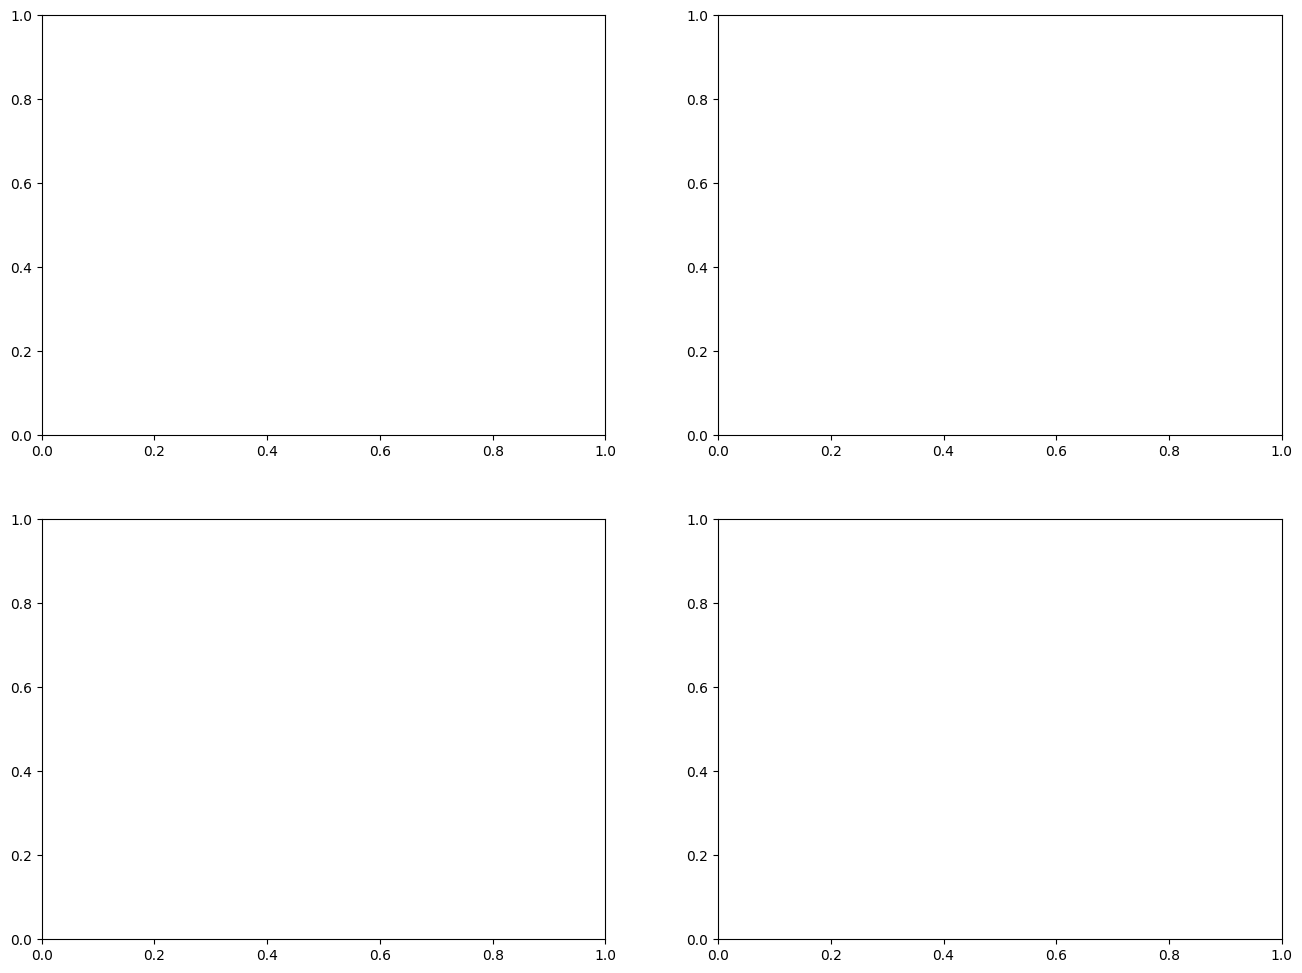

In [21]:
# Cell 9
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

studies = [('XGBoost', xgb_study), ('LightGBM', lgb_study)]

# Row 1: optimization history
for ax, (name, study) in zip(axes[0], studies):
    trials = study.trials
    values = [t.value for t in trials]
    best_so_far = np.minimum.accumulate(values)

    ax.scatter(range(len(values)), values, alpha=0.3, s=15, color='#3498db')
    ax.plot(range(len(values)), best_so_far, color='#e74c3c', linewidth=2, label='Best so far')
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV Log Loss')
    ax.set_title(f'{name} — Optimization History')
    ax.legend()

# Row 2: parameter importance
for ax, (name, study) in zip(axes[1], studies):
    try:
        importance = optuna.importance.get_param_importances(study)
        params = list(importance.keys())[:10]
        values = [importance[p] for p in params]
        ax.barh(params[::-1], values[::-1], color='#2ecc71')
        ax.set_xlabel('Importance')
        ax.set_title(f'{name} — Parameter Importance')
    except Exception as e:
        ax.text(0.5, 0.5, f'Could not compute\n{e}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{name} — Parameter Importance')

plt.tight_layout()
plt.savefig(f'{DATA}optuna_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## Tuned Feature Importance
Has tuning changed which features matter?


In [ ]:
# Cell 10
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

def get_color(f):
    if 'profile' in f:   return '#e74c3c'
    if 'last3' in f or 'last5' in f: return '#3498db'
    if 'career' in f:    return '#2ecc71'
    if any(k in f for k in ['age','height','reach','ape','weight']): return '#f39c12'
    if any(k in f for k in ['streak','days','fights_per']): return '#9b59b6'
    return '#95a5a6'

model_objs = [('XGBoost', xgb_tuned), ('LightGBM', lgb_tuned)]

for ax, (name, model) in zip(axes, model_objs):
    imp = model.feature_importances_
    feat_imp = pd.Series(imp, index=all_features).sort_values(ascending=False)
    top20 = feat_imp.head(20)
    colors = [get_color(f) for f in top20.index]

    top20.plot.barh(ax=ax, color=colors)
    ax.set_title(f'{name} (tuned) — Top 20', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('Importance')

from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#e74c3c', label='Profile'),
    Patch(color='#3498db', label='Recent Form (L3/L5)'),
    Patch(color='#2ecc71', label='Career Rolling'),
    Patch(color='#f39c12', label='Physical'),
    Patch(color='#9b59b6', label='Activity/Streak'),
    Patch(color='#95a5a6', label='Other'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f'{DATA}feature_importance_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

# Consensus ranking
print("\nCONSENSUS TOP 15 (tuned models)")
print("="*60)
ranks = pd.DataFrame()
for name, model in model_objs:
    imp = model.feature_importances_
    ranks[name] = pd.Series(imp, index=all_features).rank(ascending=False)
ranks['avg_rank'] = ranks.mean(axis=1)
consensus = ranks.sort_values('avg_rank').head(15)
consensus['group'] = [
    'PROFILE' if 'profile' in f else
    'RECENT' if ('last3' in f or 'last5' in f) else
    'CAREER' if 'career' in f else
    'PHYSICAL' if any(k in f for k in ['age','height','reach','ape','weight']) else
    'ACTIVITY' if any(k in f for k in ['streak','days','fights_per']) else
    'OTHER'
    for f in consensus.index
]
print(consensus[['avg_rank', 'group', 'XGBoost', 'LightGBM']].to_string())

## Calibration — Tuned Models


In [ ]:
# Cell 11
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

all_models = [('XGBoost', xgb_probs), ('LightGBM', lgb_probs),
              ('Ensemble', ens_probs)]

for ax, (name, probs) in zip(axes, all_models):
    fraction_pos, mean_predicted = calibration_curve(y_test, probs, n_bins=10, strategy='uniform')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.plot(mean_predicted, fraction_pos, 'o-', markersize=6, label=name)
    ax.fill_between(mean_predicted, fraction_pos, mean_predicted, alpha=0.15)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction Positive')
    ax.set_title(f'{name} (tuned)')
    ax.legend(loc='upper left')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{DATA}calibration_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

# Confidence buckets
print("\nCONFIDENCE BUCKETS (tuned ensemble)")
print("="*60)
bucket_df = pd.DataFrame({
    'prob': ens_probs,
    'pred': ens_preds,
    'actual': y_test.values,
    'correct': (ens_preds == y_test.values).astype(int),
    'confidence': np.abs(ens_probs - 0.5),
})
bins = [0, 0.03, 0.07, 0.12, 0.18, 0.25, 0.50]
labels = ['50-53%', '53-57%', '57-62%', '62-68%', '68-75%', '75%+']
bucket_df['bucket'] = pd.cut(bucket_df['confidence'], bins=bins, labels=labels)
bucket_stats = bucket_df.groupby('bucket', observed=True).agg(
    fights=('actual', 'count'),
    accuracy=('correct', 'mean'),
    avg_prob=('prob', lambda x: np.abs(x - 0.5).mean() + 0.5),
).round(3)
bucket_stats['pct'] = (bucket_stats['fights'] / len(y_test) * 100).round(1)
print(bucket_stats.to_string())

## Model Agreement — Tuned


In [22]:
# Cell 12
print("="*60)
print("MODEL AGREEMENT (tuned)")
print("="*60)

agree_both = (xgb_preds == lgb_preds)
print(f"XGB-LGB agree: {agree_both.mean():.1%} ({agree_both.sum()}/{len(y_test)})")

if agree_both.sum() > 0:
    agree_acc = accuracy_score(y_test[agree_both], xgb_preds[agree_both])
    print(f"Agreement accuracy: {agree_acc:.3f}")

disagree = ~agree_both
if disagree.sum() > 0:
    dis_acc = accuracy_score(y_test[disagree], ens_preds[disagree])
    print(f"Disagreement fights ({disagree.sum()}): ensemble acc = {dis_acc:.3f}")

MODEL AGREEMENT (tuned)
XGB-LGB agree: 96.4% (133/138)
Agreement accuracy: 0.805
Disagreement fights (5): ensemble acc = 0.400


## Save Tuned Models & Results


In [23]:
# Cell 13
import joblib

MODELS_DIR = '../models/' if os.path.exists('../models/') else './models/'
os.makedirs(MODELS_DIR, exist_ok=True)

# Save models
joblib.dump(xgb_tuned, f'{MODELS_DIR}xgb_tuned.joblib')
joblib.dump(lgb_tuned, f'{MODELS_DIR}lgb_tuned.joblib')
print(f"Tuned models saved to {MODELS_DIR}")

# Save best params
best_params = {
    'xgb': xgb_study.best_params,
    'lgb': lgb_study.best_params,
}
with open(f'{DATA}best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2, default=str)
print(f"Best params saved to {DATA}best_params.json")

# Save test predictions
test_out = test[['event_date', 'fighter_1', 'fighter_2', 'f1_win', 'weight_class']].copy()
test_out['xgb_prob'] = xgb_probs
test_out['lgb_prob'] = lgb_probs
test_out['ens_prob'] = ens_probs
test_out['ens_pred'] = ens_preds
test_out['correct']  = (ens_preds == y_test.values).astype(int)
test_out.to_csv(f'{DATA}test_predictions_tuned.csv', index=False)
print(f"Tuned predictions saved to {DATA}test_predictions_tuned.csv")

# FINAL SUMMARY
print(f"\n{'='*60}")
print(f"FINAL SUMMARY — TUNED MODELS")
print(f"{'='*60}")
print(f"Training:  {len(train)} fights | Test: {len(test)} fights")
print(f"Features:  {len(all_features)}")
print(f"Baseline:  acc={baseline_acc:.3f}  ll={baseline_ll:.3f}")
print(f"")
print(f"{'Model':<12} {'NB05 Acc':>9} {'NB06 Acc':>9} {'Δ Acc':>7} "
      f"{'NB06 AUC':>9} {'NB06 LL':>8}")
print("─" * 55)
for name in ['XGBoost', 'LightGBM', 'Ensemble']:
    b = nb05[name]
    t = tuned[name]
    print(f"{name:<12} {b['acc']:>9.3f} {t['acc']:>9.3f} {t['acc']-b['acc']:>+7.3f} "
          f"{t['auc']:>9.3f} {t['ll']:>8.3f}")

print(f"\nOptuna trials per model: 50")
print(f"CV strategy: {N_SPLITS}-fold TimeSeriesSplit")
print(f"Objective: minimize CV log loss")

Tuned models saved to ../models/
Best params saved to ./data/best_params.json
Tuned predictions saved to ./data/test_predictions_tuned.csv

FINAL SUMMARY — TUNED MODELS
Training:  5347 fights | Test: 138 fights
Features:  310
Baseline:  acc=0.580  ll=0.681

Model         NB05 Acc  NB06 Acc   Δ Acc  NB06 AUC  NB06 LL
───────────────────────────────────────────────────────
XGBoost          0.751     0.804  +0.053     0.861    0.463
LightGBM         0.746     0.783  +0.037     0.879    0.450
Ensemble         0.759     0.790  +0.031     0.870    0.454

Optuna trials per model: 50
CV strategy: 5-fold TimeSeriesSplit
Objective: minimize CV log loss
